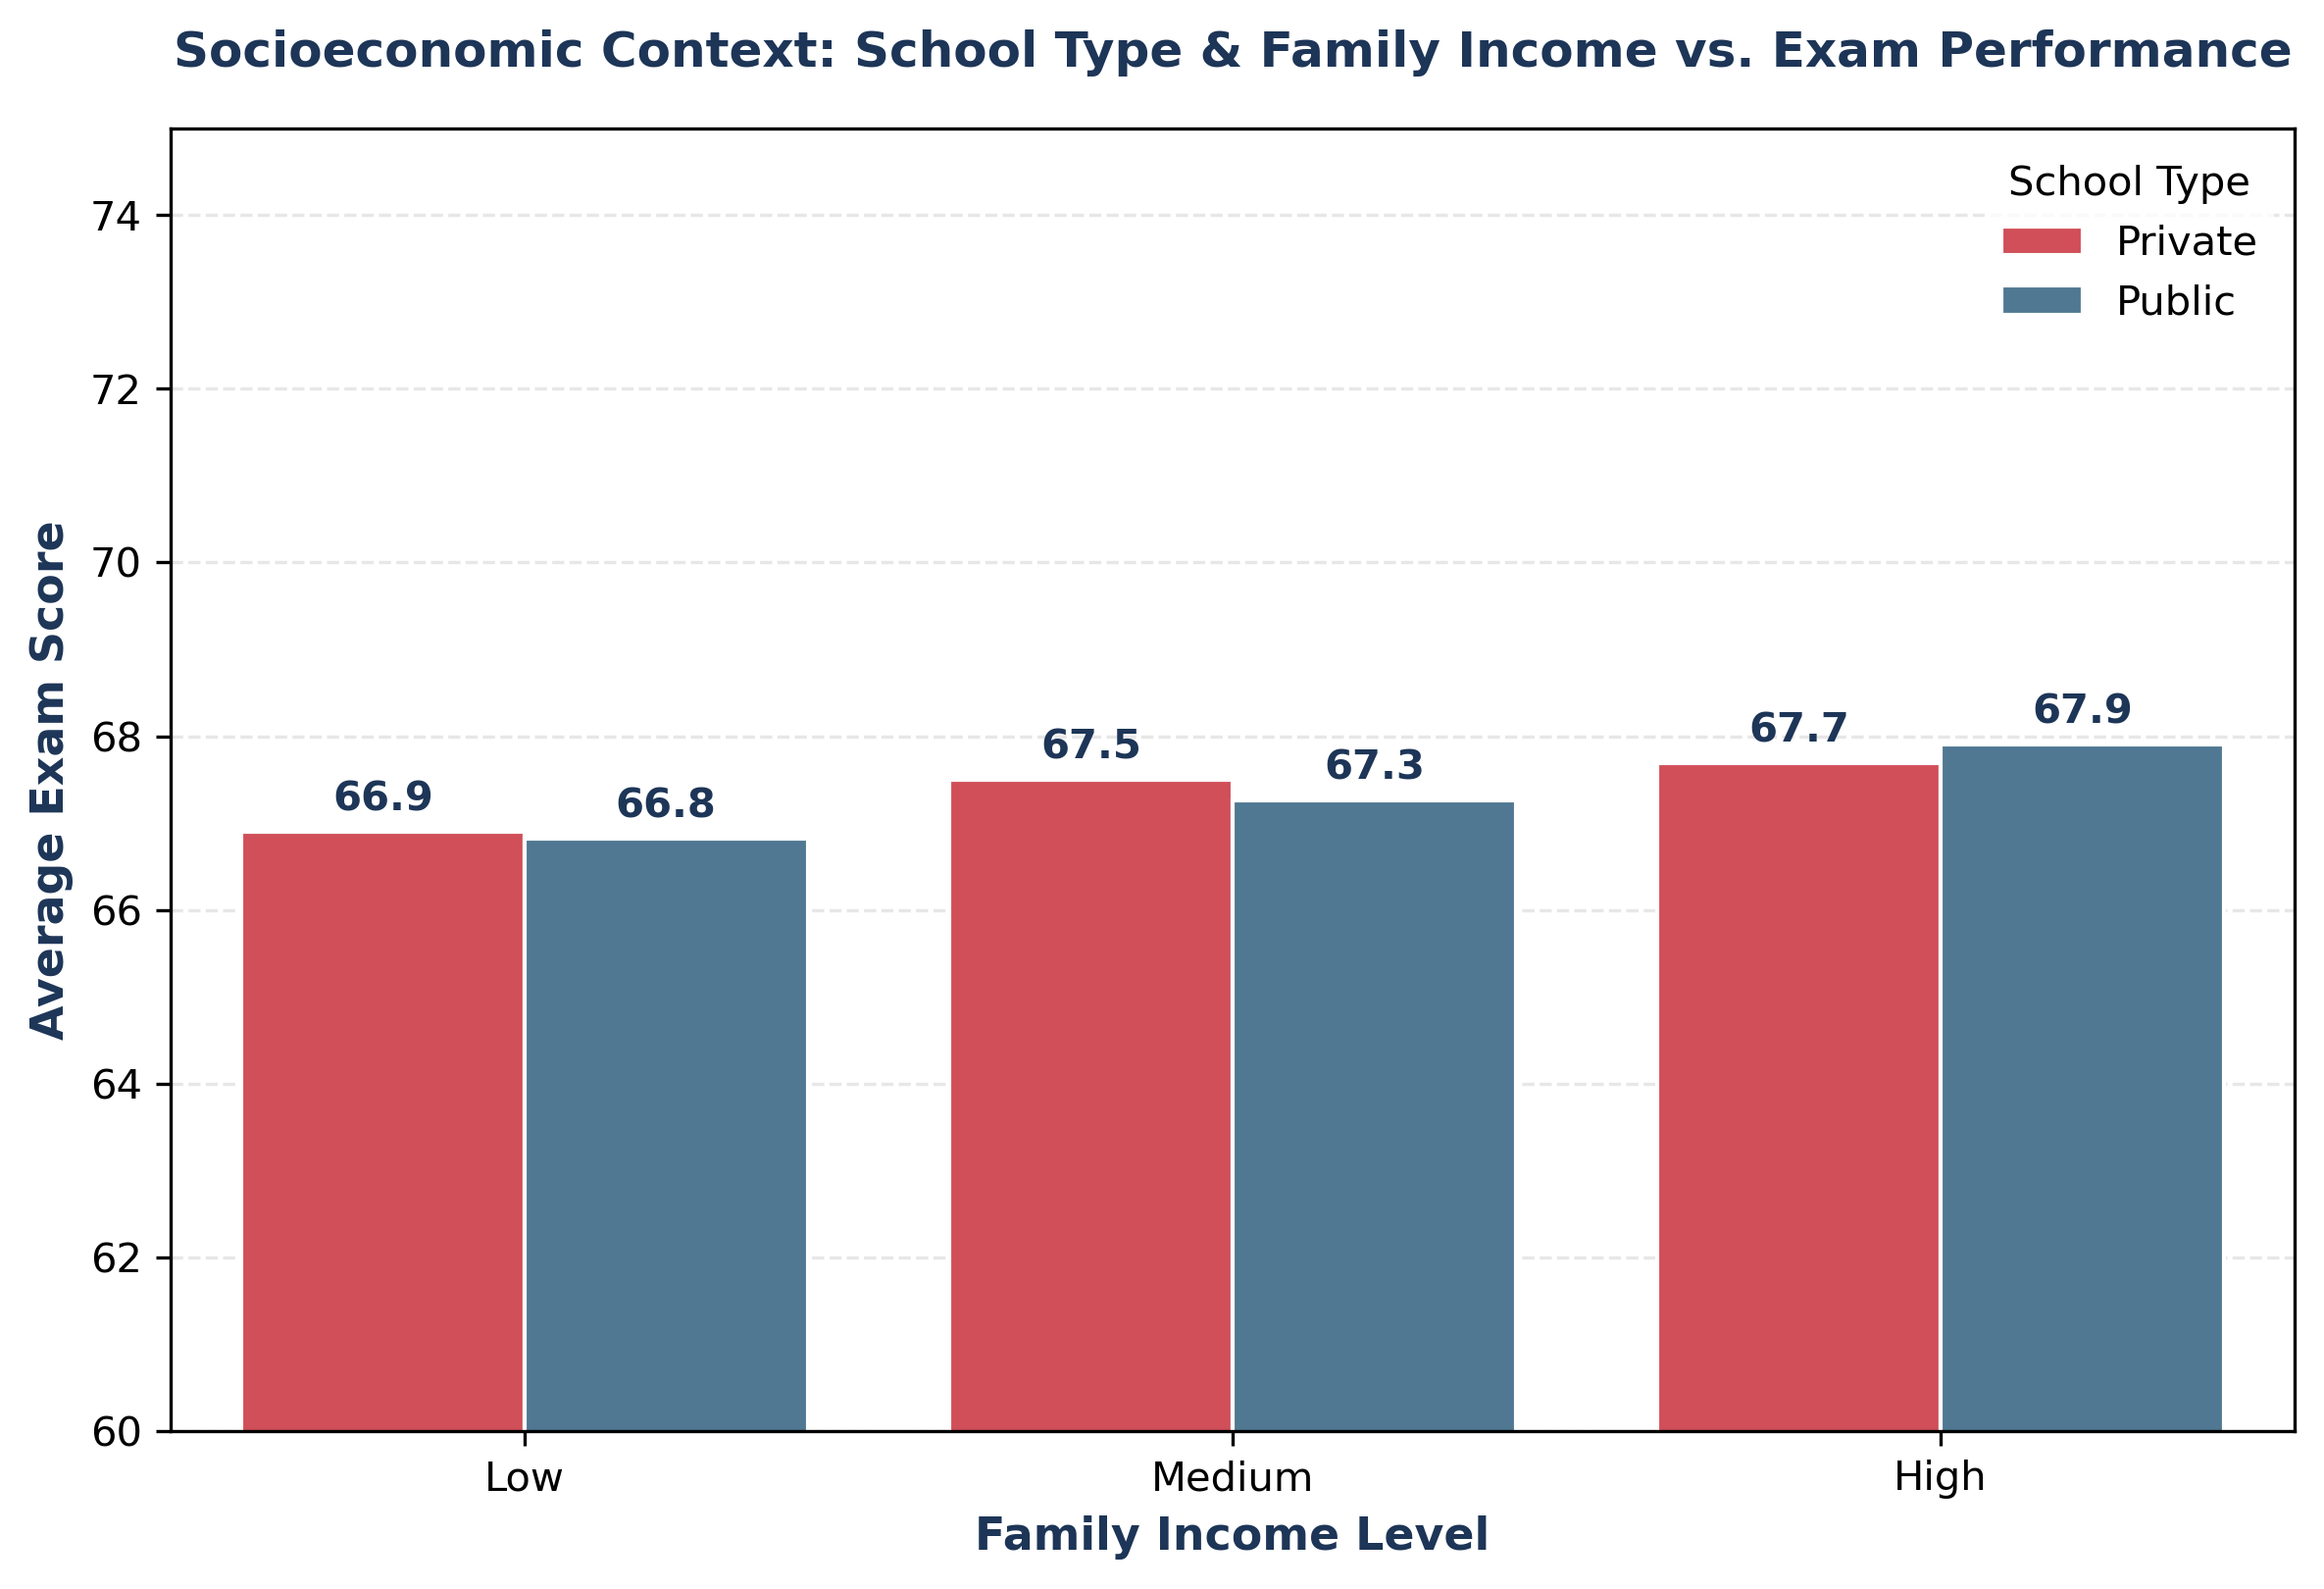

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('StudentPerformanceFactors.csv')

grouped_school = df.groupby(['Family_Income', 'School_Type'])['Exam_Score'].agg(['mean', 'count']).reset_index()

plt.figure(figsize=(8, 5.5), dpi=300)

palette = {'Public': '#457B9D', 'Private': '#E63946'}

ax = sns.barplot(
    data=grouped_school,
    x='Family_Income',
    y='mean',
    hue='School_Type',
    order=['Low', 'Medium', 'High'],
    palette=palette,
    edgecolor='white',
    linewidth=1
)

plt.title("Socioeconomic Context: School Type & Family Income vs. Exam Performance", fontsize=12, fontweight='bold', pad=15, color='#1D3557')
plt.xlabel("Family Income Level", fontsize=11, fontweight='bold', color='#1D3557')
plt.ylabel("Average Exam Score", fontsize=11, fontweight='bold', color='#1D3557')
plt.ylim(60, 75)

for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(f'{height:.1f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, color='#1D3557', fontweight='bold',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.legend(title="School Type", frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()